In [1]:
from pipeline import  run_full_experiment

In [2]:
from preprocessing import cleaning_text
print(cleaning_text("This is a great place and I loved the food!"))

['great', 'place', 'love', 'food']


In [3]:
%time results = run_full_experiment(csv_path = 'YelpData.csv')

C:\Users\alkan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Sistem belirtilen dosyayı bulamıyor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\alkan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\alkan\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alkan\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\alkan\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(e

CPU times: total: 15min 56s
Wall time: 6min 7s


In [4]:
print(results['best_info'])

{'comb_name': '4. Hybrid + SMOTE', 'model_name': 'XGBoost', 'pipeline': Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None

In [ ]:
# Özet: En iyi base model bilgileri
best_info = results["best_info"]
best_score = results["best_score"]

print("Best Combination :", best_info["comb_name"])
print("Best Model       :", best_info["model_name"])
print("Weighted F1      :", round(best_score, 4))

In [ ]:
# Sınıf bazlı metrikler: classification report
from pprint import pprint

print("\nClassification Report (base best model):\n")
print(best_info["classification_report"])

In [ ]:
# Confusion matrix: görsel inceleme
import seaborn as sns
import matplotlib.pyplot as plt

cm = best_info["confusion_matrix"]

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (base best model)")
plt.show()

In [ ]:
# Hyperparametre araması (RandomizedSearchCV) sonuçları

tuned_search = results.get("tuned_search")

if tuned_search is None:
    print("Tuning henüz çalışmadı veya en iyi model Hybrid+SMOTE XGBoost değildi.")
else:
    print("CV Weighted F1 (best):", round(tuned_search.best_score_, 4))
    print("\nBest Params:")
    for k, v in tuned_search.best_params_.items():
        print(f"  {k}: {v}")

In [ ]:
# Hyperparametre araması (RandomizedSearchCV) sonuçları

tuned_search = results.get("tuned_search")

if tuned_search is None:
    print("Tuning henüz çalışmadı veya en iyi model Hybrid+SMOTE XGBoost değildi.")
else:
    print("CV Weighted F1 (best):", round(tuned_search.best_score_, 4))
    print("\nBest Params:")
    for k, v in tuned_search.best_params_.items():
        print(f"  {k}: {v}")

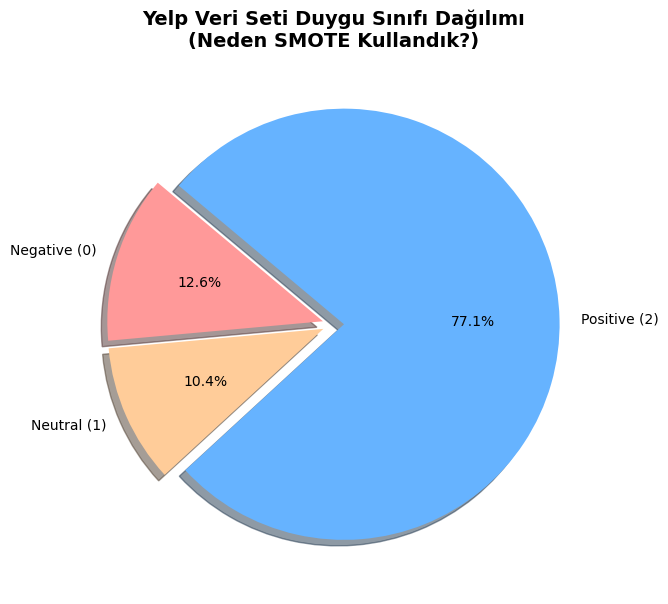

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tüm etiketleri (y_train ve y_test) birleştirip genel dağılıma bakalım
all_labels = pd.concat([results['y_train'], results['y_test']])
class_counts = all_labels.value_counts().sort_index() # 0, 1, 2 sırasına dizer

label_names= ['Negative (0)', 'Neutral (1)', 'Positive (2)']
colors = ['#ff9999', '#ffcc99', '#66b3ff'] # Kırmızı, Turuncu, Mavi tonları

plt.figure(figsize=(7, 7))
plt.pie(class_counts, labels=label_names, autopct='%1.1f%%', 
        colors=colors, startangle=140, shadow=True, explode=(0.05, 0.05, 0.05))
plt.title("Yelp Veri Seti Duygu Sınıfı Dağılımı\n(Neden SMOTE Kullandık?)", fontsize=14, fontweight='bold')
plt.show()

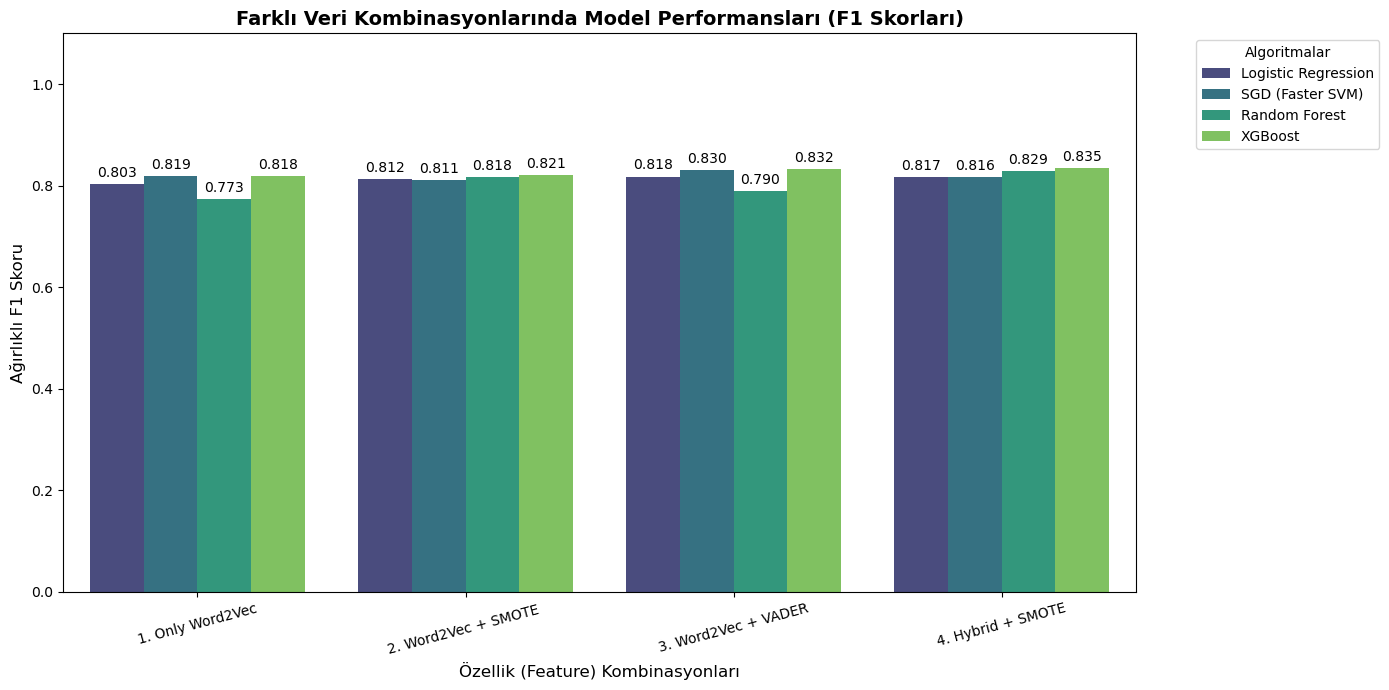

In [8]:
# 'results' listesindeki verileri Pandas DataFrame'e çevirelim
deney_verileri = []
for res in results['results']:
    # NaN (Hata almış) olanları grafikte göstermemek için filtreleyebiliriz
    if pd.notna(res.f1_score): 
        deney_verileri.append({
            'Model': res.model_name,
            'Kombinasyon': res.combination,
            'F1_Skoru': res.f1_score
        })

df_sonuclar = pd.DataFrame(deney_verileri)

# Grafiği çizdirelim
plt.figure(figsize=(14, 7)) # Değerler sığsın diye grafiği biraz daha genişlettik

# sns.barplot'u 'ax' adlı bir değişkene atıyoruz ki daha sonra üzerine işlem yapabilelim
ax = sns.barplot(data=df_sonuclar, x='Kombinasyon', y='F1_Skoru', hue='Model', palette='viridis')

# SÜTUNLARIN ÜZERİNE DEĞERLERİ YAZDIRMA KISMI
for container in ax.containers:
    # fmt='%.3f' ile virgülden sonra 3 basamak gösteriyoruz (örn: 0.842)
    # padding=3 ile sayının sütunla arasına hafif bir boşluk bırakıyoruz
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.title('Farklı Veri Kombinasyonlarında Model Performansları (F1 Skorları)', fontsize=14, fontweight='bold')
plt.xlabel('Özellik (Feature) Kombinasyonları', fontsize=12)
plt.ylabel('Ağırlıklı F1 Skoru', fontsize=12)

# X eksenindeki yazıları daha okunaklı yapmak için hafif eğiyoruz
plt.xticks(rotation=15) 
# Değerler en üstte kesilmesin diye Y ekseninin tavanını biraz yükseltebiliriz
plt.ylim(0, 1.1) 

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Algoritmalar')
plt.tight_layout()
plt.show()

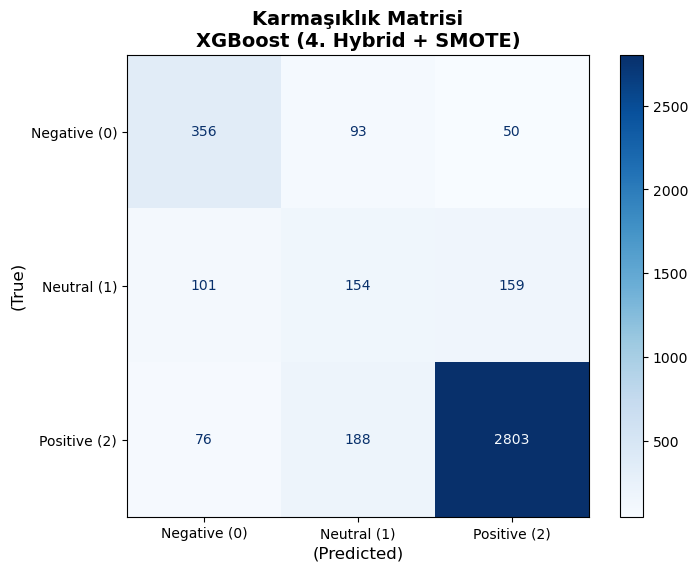

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# En iyi modelin test sonuçlarını alıyoruz
en_iyi_y_test = results['best_info']['y_test']
en_iyi_tahminler = results['best_info']['preds']
en_iyi_model_ismi = results['best_info']['model_name']
en_iyi_kombinasyon = results['best_info']['comb_name']

# Karmaşıklık Matrisini hesapla
cm = confusion_matrix(en_iyi_y_test, en_iyi_tahminler)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

# Görselleştir
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title(f"Karmaşıklık Matrisi\n{en_iyi_model_ismi} ({en_iyi_kombinasyon})", 
          fontsize=14, fontweight='bold')
plt.xlabel("(Predicted)", fontsize=12)
plt.ylabel("(True)", fontsize=12)
plt.show()